In [1]:
# Import libraries for data handling and analysis
import pandas as pd  # for data manipulation
import numpy as np  # for numerical operations


# Import libraries for data visualization
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns  # for advanced visualizations


# Import scikit-learn tools for machine learning
from sklearn.model_selection import train_test_split  # for splitting data
from sklearn.preprocessing import StandardScaler  # for feature scaling
from sklearn.ensemble import RandomForestRegressor  # for regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # for evaluation


ModuleNotFoundError: No module named 'seaborn'

In [ ]:
# Read the gold price dataset with 'Date' parsed as datetime
df = pd.read_csv(r"C:\\Users\\JAGAN BEHERA\\GOLD PRICE\\GOLD_PRICE_DATASET\\gld_price_data.csv", parse_dates=['Date'])
print("Data loaded successfully!")


Data loaded successfully!


In [ ]:
# Why Oil Affects Gold Prices:
# Inflation Hedge:
# Both oil and gold are considered hedges against inflation.
# When oil prices rise → production/transportation costs increase → inflation rises → investors buy gold to preserve value.
# Why Silver Affects Gold Prices:
# Precious Metals Correlation:
# Gold and silver are both precious metals with similar demand drivers (jewelry, industrial use, investment).
# They often move together in price trends.
# Gold-Silver Ratio:
  #Traders watch the gold-to-silver price ratio (historically ~60:1).
  #If the ratio is too high → Silver is undervalued → Investors buy silver, sometimes selling gold.
 #If the ratio is too low → Silver is overvalued → Investors shift to gold.


In [ ]:
# Print basic information about the dataset
print("\n=== Dataset Visualization ===")
print(f"Shape: {df.shape}")  # number of rows and columns
print(f"Columns: {df.columns.tolist()}")  # list of column names
print("\nFirst 5 rows:")
print(df.head())  # preview the first few records
print("\nData types:")
print(df.dtypes)  # show data types of each column


# Save the cleaned dataframe for reuse
df.to_pickle('gold_price_data_clean.pkl')



=== Dataset Visualization ===
Shape: (2290, 6)
Columns: ['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD']

First 5 rows:
        Date          SPX        GLD        USO     SLV   EUR/USD
0 2008-01-02  1447.160034  84.860001  78.470001  15.180  1.471692
1 2008-01-03  1447.160034  85.570000  78.370003  15.285  1.474491
2 2008-01-04  1411.630005  85.129997  77.309998  15.167  1.475492
3 2008-01-07  1416.180054  84.769997  75.500000  15.053  1.468299
4 2008-01-08  1390.189941  86.779999  76.059998  15.590  1.557099

Data types:
Date       datetime64[ns]
SPX               float64
GLD               float64
USO               float64
SLV               float64
EUR/USD           float64
dtype: object


In [ ]:
# Print missing values before cleaning
print("\nMissing values before cleaning:")
print(df.isnull().sum())


# Drop rows with missing values
df.dropna(inplace=True)


# Check for duplicate rows
print("\nNumber of duplicates:", df.duplicated().sum())


# Convert 'Date' to datetime and extract year, month, day
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day


# Display cleaned and updated data
print("\nData after cleaning:")
print(df.head())



Missing values before cleaning:
Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

Number of duplicates: 0

Data after cleaning:
        Date          SPX        GLD        USO     SLV   EUR/USD  Year  \
0 2008-01-02  1447.160034  84.860001  78.470001  15.180  1.471692  2008   
1 2008-01-03  1447.160034  85.570000  78.370003  15.285  1.474491  2008   
2 2008-01-04  1411.630005  85.129997  77.309998  15.167  1.475492  2008   
3 2008-01-07  1416.180054  84.769997  75.500000  15.053  1.468299  2008   
4 2008-01-08  1390.189941  86.779999  76.059998  15.590  1.557099  2008   

   Month  Day  
0      1    2  
1      1    3  
2      1    4  
3      1    7  
4      1    8  


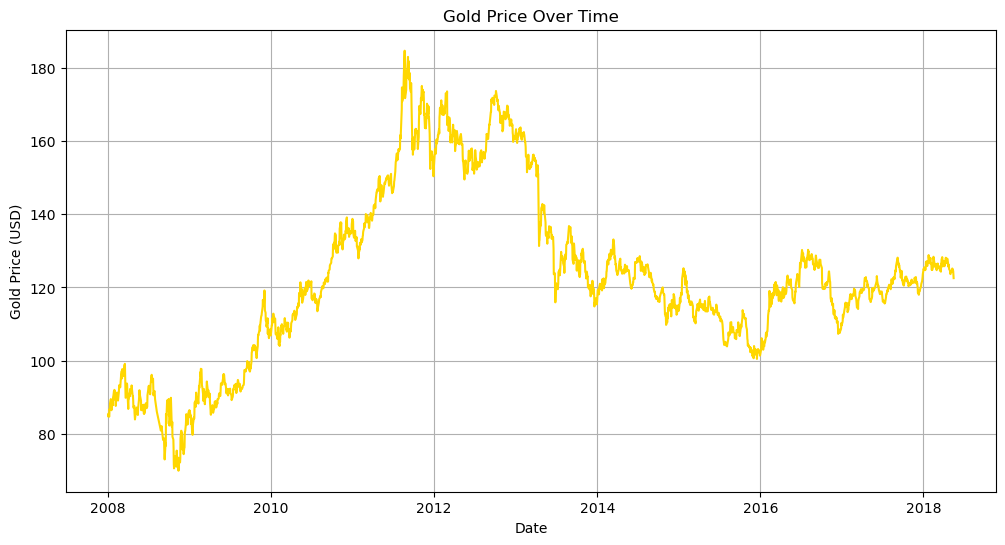

In [ ]:
# Plot gold price over time
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['GLD'], color='gold')
plt.title('Gold Price Over Time')
plt.xlabel('Date')
plt.ylabel('Gold Price (USD)')
plt.grid(True)
plt.show()



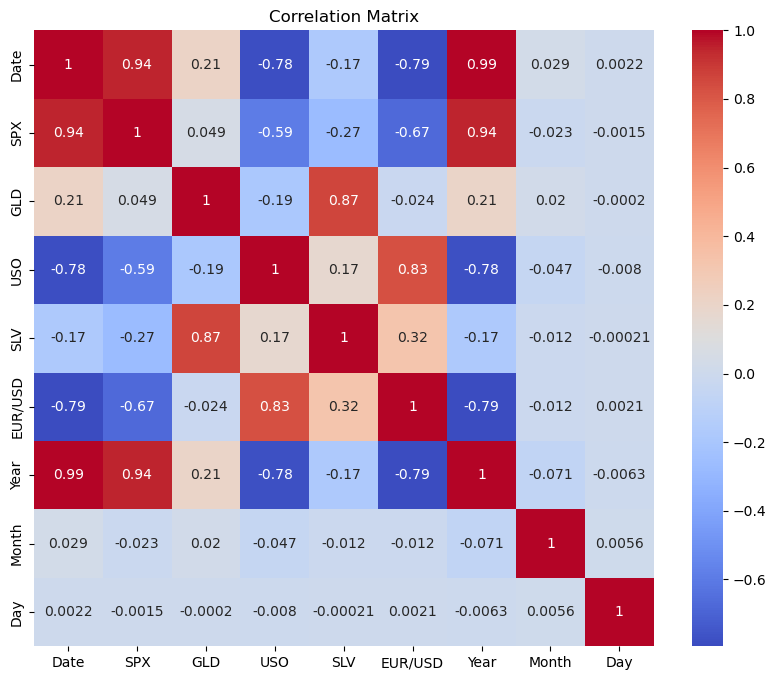

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [ ]:
# Select features (independent variables)
X = df[['SPX', 'USO', 'SLV', 'EUR/USD']]

# Target variable (gold price)
y = df['GLD']

# Split the data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Show the number of samples in each set
print("\nData splitting results:")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Data splitting results:
Training set size: 1832 samples
Test set size: 458 samples


In [ ]:
# Initialize the standard scaler
scaler = StandardScaler()

# Fit the scaler on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back into DataFrames for readability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Display first few rows of scaled training data
print("\nFirst 5 rows of scaled training data:")
print(X_train_scaled_df.head())



First 5 rows of scaled training data:
        SPX       USO       SLV   EUR/USD
0 -0.479393  0.221693  1.232925 -0.229177
1  0.816076 -1.021600 -0.521172 -1.147799
2 -0.803530  3.930749 -0.222975  2.300308
3 -1.652074 -0.162265 -1.269119  0.037729
4  1.285519 -1.052581 -0.365408 -1.689919


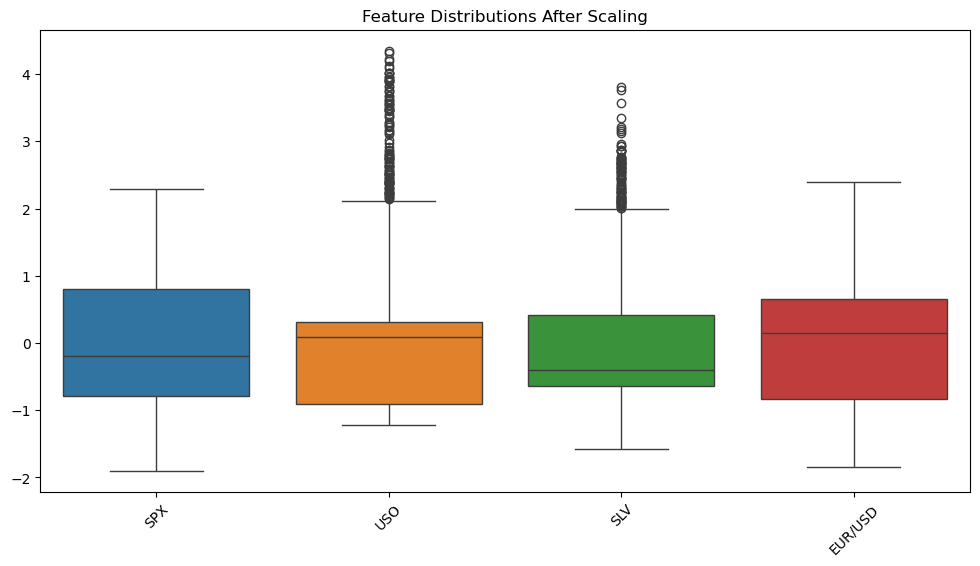

In [ ]:
# Boxplot to visualize the distribution of scaled features
plt.figure(figsize=(12, 6))
sns.boxplot(data=X_train_scaled_df)
plt.title('Feature Distributions After Scaling')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Create a Random Forest Regressor model with 100 trees
model = RandomForestRegressor(n_estimators=100, random_state=42)
print("\nModel selected: Random Forest Regressor")



Model selected: Random Forest Regressor


In [ ]:
# Train the model on the training data
model.fit(X_train_scaled, y_train)

# Predict on both train and test sets
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Compare predictions with actual values
train_results = pd.DataFrame({'Actual': y_train, 'Predicted': y_train_pred})
test_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})

print("\nSample predictions on training set:")
print(train_results.head())
print("\nSample predictions on test set:")
print(test_results.head())


Sample predictions on training set:
          Actual   Predicted
1018  160.539993  158.409995
1870  120.900002  120.987602
118    94.440002   94.401901
220    84.519997   83.467299
2053  122.599998  122.321698

Sample predictions on test set:
          Actual   Predicted
2178  122.320000  122.466799
1271  129.899994  130.288803
1268  126.980003  127.725999
44     96.500000   96.698897
2025  117.580002  118.972401


In [ ]:
# Define a function to calculate error metrics
def evaluate_model(y_true, y_pred, set_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name} Set Evaluation:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
    

In [ ]:
# Evaluate model on both sets
train_metrics = evaluate_model(y_train, y_train_pred, "Training")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")



Training Set Evaluation:
MAE: 0.47
MSE: 0.75
RMSE: 0.87
R² Score: 1.00

Test Set Evaluation:
MAE: 1.24
MSE: 5.48
RMSE: 2.34
R² Score: 0.99


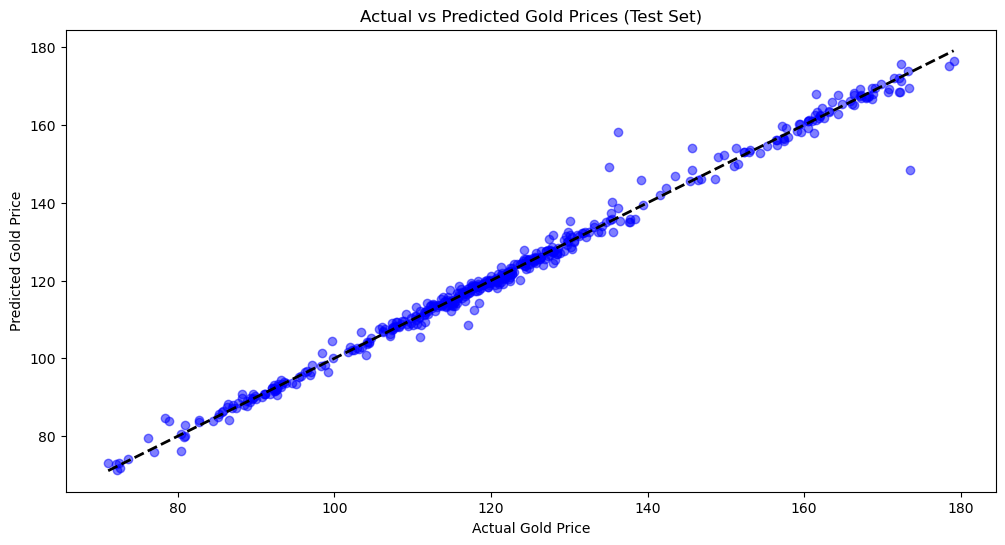

In [ ]:
# Plot actual vs predicted for test set
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_test_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Gold Price')
plt.ylabel('Predicted Gold Price')
plt.title('Actual vs Predicted Gold Prices (Test Set)')
plt.show()


In [ ]:
# Create a new set of input values (hypothetical scenario)
new_data = pd.DataFrame({
    'SPX': [2700],
    'USO': [75],
    'SLV': [18],
    'EUR/USD': [1.15]
})

# Scale the new data with the same scaler used earlier
new_data_scaled = scaler.transform(new_data)

# Predict gold price for the new input
predicted_price = model.predict(new_data_scaled)

print(f"\nPredicted Gold Price for new data: ${predicted_price[0]:.2f}")

# Print the actual range of gold prices in the original dataset
print(f"Actual GLD range in dataset: ${df['GLD'].min():.2f} - ${df['GLD'].max():.2f}")



Predicted Gold Price for new data: $124.21
Actual GLD range in dataset: $70.00 - $184.59
